In [ ]:
base_folder_path = r"../../backbone/en-zh-opennmt/"
save_folder_path = r"./analysis_results_data/"
wsd_folder_path = r"../../wsd/"
salient_wsd_folder_path = r"../../salient_with_wsd/"
pos_tagging_folder_path = r"../../pos_tagging/"
from analysis_helper import *
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
def print_translations():
    with open(f"{base_folder_path}/en-zh.en-filtered.en.subword.test.desubword", 'r', encoding='utf-8') as en_file, \
         open(f"{base_folder_path}/zh.translated.desubword", 'r', encoding='utf-8') as zh_salient_file, \
         open(f"{wsd_folder_path}/zh.translated.desubword", 'r', encoding='utf-8') as zh_wsd_file, \
         open(f"{salient_wsd_folder_path}/zh.translated.desubword", 'r', encoding='utf-8') as zh_salient_wsd_file, \
         open(f"{pos_tagging_folder_path}/zh.base.translated.desubword", 'r', encoding='utf-8') as zh_pos_tagging_file, \
         open(f"{base_folder_path}/zh.base.translated.desubword", 'r', encoding='utf-8') as zh_base_file, \
         open(f"{base_folder_path}/en-zh.zh-filtered.zh.subword.test.desubword", encoding="utf-8") as zh_correct_file:

        for en_line, zh_salient_line, zh_wsd_line, zh_salient_wsd_line, zh_pos_tagging_line, zh_base_line, zh_correct_line in zip(en_file, zh_salient_file, zh_wsd_file, zh_salient_wsd_file, zh_pos_tagging_file, zh_base_file, zh_correct_file):
            en_line = en_line.strip()
            zh_salient_line = zh_salient_line.strip()
            zh_wsd_line = zh_wsd_line.strip()
            zh_salient_wsd_line = zh_salient_wsd_line.strip()
            zh_pos_tagging_line = zh_pos_tagging_line.strip()
            zh_base_line = zh_base_line.strip()
            zh_correct_line = zh_correct_line.strip()
            
            print(f"English:                     {en_line}")
            print(f"Chinese (salient):           {zh_salient_line}")
            print(f"Chinese (wsd):               {zh_wsd_line}")
            print(f"Chinese (salient with wsd):  {zh_salient_wsd_line}")
            print(f"Chinese (pos tagging):       {zh_pos_tagging_line}")
            print(f"Chinese (base):              {zh_base_line}")
            print(f"Chinese (correct):           {zh_correct_line}")
            print("-" * 50)

print_translations()

English:                     Dictatorships in Czechoslovakia, East Germany, Estonia, Latvia, Lithuania, Mali, Madagascar, Poland, the Philippines, Serbia, Slovenia, I could go on, and now Tunisia and Egypt.
Chinese (salient):           在捷克斯洛伐克,东德国, 爱沙尼亚、拉特维亚、马里兰、马里亚、马达加斯加、 菲律宾、塞罗维亚、斯洛文尼亚、现在和埃及。
Chinese (wsd):               东海岸的心脏起搏器,德国、德国、德国、利沙尼亚 利沙尼亚、拉斯维亚、利比亚 毛里斯科维亚、马里兰、波兰、波兰、波兰 利比亚,现在我也可以继续
Chinese (salient with wsd):  东海岸的心脏起搏器,德国、德国、德国、利沙尼亚 利沙尼亚、拉斯维亚、利比亚 毛里斯科维亚、马里兰、波兰、波兰、波兰 利比亚,现在我也可以继续
Chinese (pos tagging):       禁止在捷克、东德国、 爱沙沙尼亚、陶宛、马里斯加、马达加斯加、 普利斯和塞尔维亚等,我可以继续下去, 现在是突尼西亚和埃及。
Chinese (base):              在捷克洛伐克的达基地, 东德国,爱沙尼亚、拉塔维亚、马斯达加、马里斯加、马达加斯加、 宾夕法尼亚、塞尔维亚、斯洛文尼亚、 斯洛文尼亚、突尼西亚、埃及。
Chinese (correct):           在捷克斯洛伐克,东德 爱沙尼亚,拉脱维亚,立陶宛, 马里,马达加斯加, 波兰,菲律宾, 塞尔维亚,斯洛维尼亚的独裁政府,我可以继续, 还有现在的突尼斯和埃及。
--------------------------------------------------
English:                     I don't know what they're going to do with all that stuff.
Chinese (salient):           我不知道他们要怎么处理这些东西。
Chinese (wsd)

## Base model (fine-tuned) Analysis

In [2]:
en_path = f"{base_folder_path}/en-zh.en-filtered.en.subword.test.desubword"
zh_trans_path = f"{base_folder_path}/zh.base.translated.desubword"
zh_correct_path = f"{base_folder_path}/en-zh.zh-filtered.zh.subword.test.desubword"

df_sentences, df_mismatches = analyze_translations(en_path, zh_trans_path, zh_correct_path, save_path=save_folder_path)

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\mgagi\AppData\Local\Temp\jieba.cache
Loading model cost 1.460 seconds.
Prefix dict has been built successfully.


### Sort by METEOR (asc), edit distance (desc)

Edit distance is used as well to highlight sentences that are semantically different

In [4]:
df_sentences.sort_values(by=['METEOR', 'EditDistance'], ascending=[True, False]).head()

,English,Chinese (model),Chinese (correct),METEOR,BLEU,EditDistance
1497,RF: Here's it going down a pathway.,RF:现在沿着这条道路往下走。,"啊,我喜欢它--鲍勃,他正在下坡",0.0,0.0,16
555,And Laurie's going to talk about this one a li...,Laurie将会有一点点介绍。,劳里待会儿会说点这方面的东西,0.0,0.0,15
824,It's not civically rich enough for them to go ...,公民教育无法充分利用这些资源。,"那儿太冷清了,他们没兴趣",0.0,0.0,15
487,"Now, this is a conversation that often calls u...",这样的对话经常 带来许多罪恶感,这个话题时常让我们觉得很内疚。,0.0,0.0,14
281,Thank you. Namaste.,谢谢。纳姆斯特。,"而平凡如你我,只有两只眼睛",0.0,0.0,13


### Sort sentences based on input length

In [5]:
df_sentences.sort_values(by='English', key=lambda x: x.str.len()).head()

,English,Chinese (model),Chinese (correct),METEOR,BLEU,EditDistance
1316,36!,36!,你知道有多少种吗?36!,0.225904,0.009549,9
853,Hope.,希望,那就是希望,0.178571,0.024066,3
1925,Five.,五,观众:5。阿瑟:5。,0.000000,0.000000,10
230,Awful.,糟糕。,糟糕透了。,0.263158,0.065419,2
525,Enough.,够了。,够了。,0.981481,0.562341,0


### Metric Correlation

In [6]:
correlation_matrix = df_sentences[['METEOR', 'BLEU', 'EditDistance']].corr()

print("\nMetric Correlations:")
print(f"METEOR vs BLEU: {correlation_matrix.loc['METEOR', 'BLEU']:.2f}")
print(f"Edit Distance vs METEOR: {correlation_matrix.loc['EditDistance', 'METEOR']:.2f}")


Metric Correlations:
METEOR vs BLEU: 0.78
Edit Distance vs METEOR: -0.22


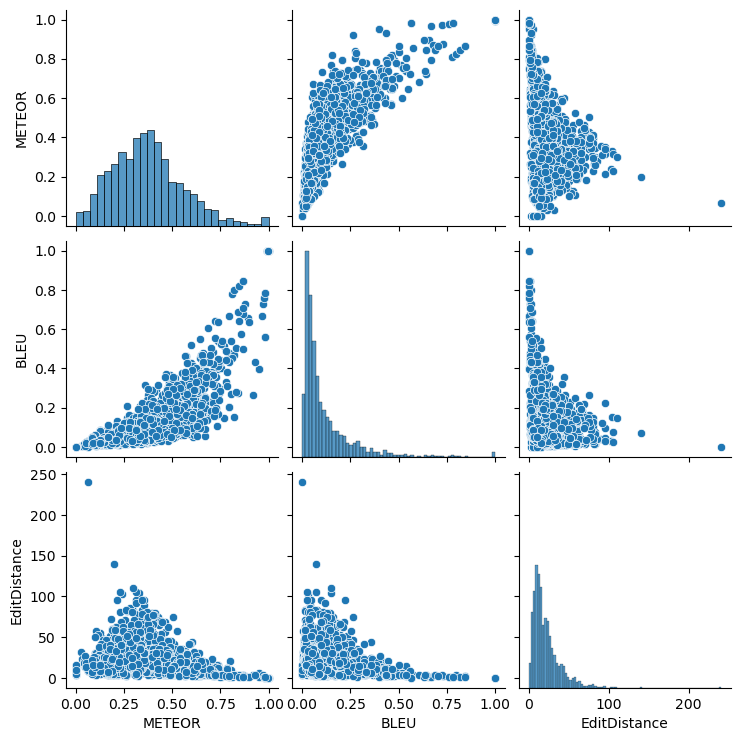

In [ ]:
# when i=j --> frequency distribution
sns.pairplot(df_sentences[['METEOR', 'BLEU', 'EditDistance']])

### High error translations (low score, edit_distance > 0.5*sentence length(?))

### Mismatches

Missing words from the reference that do not appear in the model output.

In [ ]:
# Lists of available fonts (for debugging purposes)
# import matplotlib.font_manager as fm


# for font in fm.findSystemFonts():
#     print(fm.FontProperties(fname=font).get_name())

In [ ]:
pos_mismatch_summary = df_mismatches.groupby("POS")["MismatchCount"].agg(['count', 'sum']).reset_index()
pos_mismatch_summary.columns = ["POS", "UniqueWordCount", "TotalMismatches"]
pos_mismatch_summary = pos_mismatch_summary.sort_values(by="TotalMismatches", ascending=False)
pos_mismatch_summary.head()

,POS,UniqueWordCount,TotalMismatches
41,v,1477,4567
19,n,1878,3482
29,r,147,1740
6,d,239,1622
46,x,42,1184


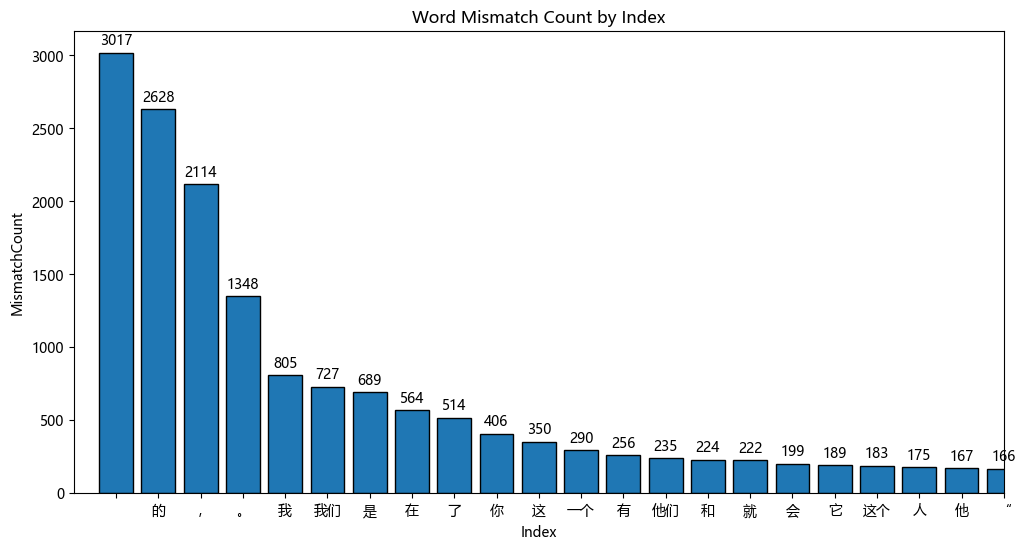

In [ ]:
plt.rcParams["font.family"] = ["Microsoft YaHei"]

df_plot_mismatches = df_mismatches.reset_index(drop=True)
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(df_plot_mismatches['Word'], df_plot_mismatches['MismatchCount'], edgecolor='black', linewidth=1.0)
ax.bar_label(bars, fmt='%d', padding=3)
ax.set_xlabel("Index")
ax.set_ylabel("MismatchCount")
ax.set_xlim(-1, 21)
ax.set_title("Word Mismatch Count by Index (Top 20)")
plt.show()

### POS table <br>
Link to POS table <br>
https://blog.csdn.net/Yellow_python/article/details/83991967

### Jieba POS Tagging Table (v0.39)

| Tag | Description | Examples (Chinese) | Count |
| :-- | :-- | :-- | :-- |
| a | Adjective | 高 明 尖 诚 粗陋 冗杂 (tall, bright, sharp) | 4,306 |
| ad | Adverbial Adjective | 努目 完全 努力 (staring, complete, effort) | 110 |
| ag | Adjective Morpheme | 详 笃 睦 奇 (detailed, sincere) | 46 |
| an | Nominal Adjective | 麻生 猥琐 腐生 (awkward, filthy) | 40 |
| b | Distinctive Word | 劣等 洲际性 超常规 (inferior, intercontinental) | 1,363 |
| c | Conjunction | 再者说 倘 只此 (furthermore, if) | 504 |
| d | Adverb | 幸免 绝对 急速 (fortunately, absolutely) | 2,422 |
| df | Negative Adverb ("Don't") | 不要 (don't) | 1 |
| dg | Adverbial Morpheme | 俱 辄 (all, frequently) | 2 |
| e | Interjection | 哎 哇呀 啊哈 (ah, wow, aha) | 34 |
| f | Locative | 内侧 面前 沿街 (inside, front, along street) | 351 |
| g | Morpheme | 媸 璇 戬 (rare characters) | 969 |
| h | Prefix | 非 超低 (non-, ultra-low) | 2 |
| i | Idiom | 沧海一粟 一望无边 (a drop in the ocean) | 25,583 |
| j | Abbreviation | 交警 青委 (traffic police, youth committee) | 1,396 |
| k | Suffix | 型 者 式 们 (-type, -er, -style) | 4 |
| l | Set Phrase | 不懂装懂 十字路口 (pretend to know, crossroads) | 17,721 |
| m | Numeral | 九六 十二 丙戌 (96, 12, Bingxu year) | 13,178 |
| mg | Numeral Morpheme | 寅 巳 (Yin, Si - earthly branches) | 2 |
| mq | Measure-Numeral | 半年度 四方面 (half-year, four aspects) | 80 |
| n | Noun | 男性 气压 商业智能 (male, air pressure, BI) | 117,902 |
| ng | Noun Morpheme | 诀 卉 茗 (skill, flora, tea) | 280 |
| nr | Person Name | 雍正皇帝 小甜甜 (Emperor Yongzheng, Sweetie) | 72,842 |
| ns | Place Name | 南非 广州 佛山 (South Africa, Guangzhou) | 17,706 |
| nt | Organization | 铁道部 联想集团 (Ministry of Railways, Lenovo) | 4,713 |
| nz | Proper Noun | 培根 圣战士 (Bacon, Holy Warrior) | 10,441 |
| o | Onomatopoeia | 咝 飕 哇哇 (hiss, whoosh, wailing) | 247 |
| p | Preposition | 顺着 除了 自 (along, except, from) | 114 |
| q | Measure Word | 毫厘 立方米 张 (millimeter, cubic meter, sheet) | 232 |
| r | Pronoun | 那些 鄙人 他 (those, I, he) | 759 |
| s | Locality | 世外 手下 耳边 (otherworldly, underhand, ear) | 591 |
| t | Time | 月初 昔年 佳日 (month start, past years) | 1,768 |
| u | Particle | 等等 似的 的话 (etc., like, 's) | 20 |
| v | Verb | 孕育 遭殃 创生 (conceive, suffer, create) | 34,761 |
| vd | Adverbial Verb | 狡辩 持续 (quibble, persist) | 3 |
| vg | Verb Morpheme | 悖 谏 濯 (violate, advise, cleanse) | 160 |
| x | Non-Morpheme | 舭 躅 蜓 (rare characters) | 367 |
| y | Modal Particle | 呀 呗 啦 (ah, well, la) | 49 |
| z | Status Word | 飘飘 慢慢儿 (floating, slowly) | 2,624 |

### Special Structural Particles

| Tag | Character | Function |
| :-- | :-- | :-- |
| ud | 得 | Complement marker |
| ug | 过 | Experiential aspect |
| uj | 的 | Possessive/Gentive marker |
| ul | 了 | Perfective aspect |
| uv | 地 | Adverbial marker |
| uz | 着 | Progressive aspect |

This table follows the **ICTCLAS standard** from the Chinese Academy of Sciences.

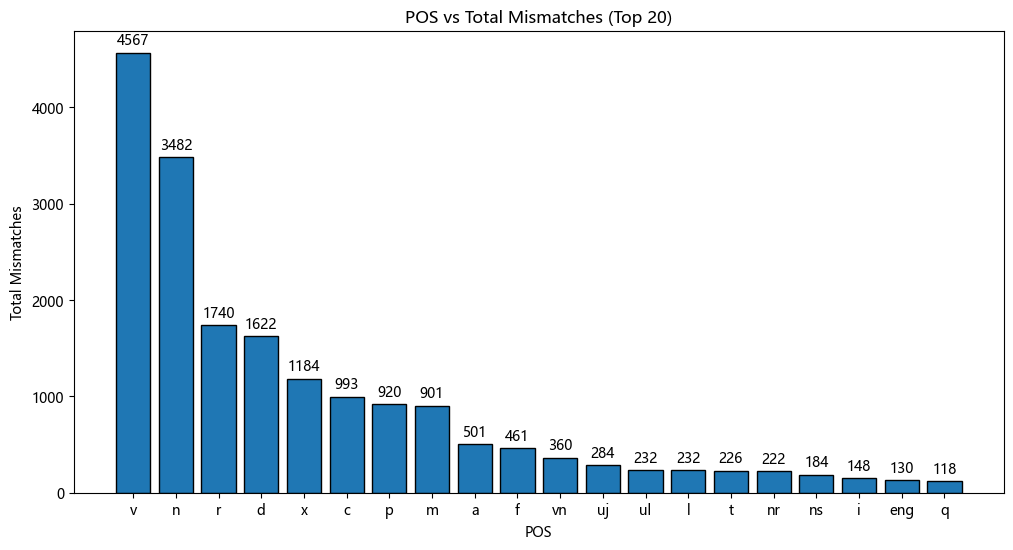

In [20]:
plt.rcParams["font.family"] = ["Microsoft YaHei"]

fig, ax = plt.subplots(figsize=(12, 6))
top_n = 20
df_plot_pos = pos_mismatch_summary.head(top_n)
bars = ax.bar(df_plot_pos['POS'], df_plot_pos['TotalMismatches'], edgecolor='black', linewidth=1.0)
ax.bar_label(bars, fmt='%d', padding=3)
ax.set_xlabel("POS")
ax.set_ylabel("Total Mismatches")
ax.set_title(f"POS vs Total Mismatches (Top {top_n})")
plt.show()

### Result findings
- Mistranslated Entity
- Not capturing the correct sense
  - e.g And in summer, here, killer wasps.
  - e.g 法律人员 vs 合法的人 in "Humans and legal persons are not synonymous."
- Cannot translate well if 1 token for input (?)
  - e.g Us.;美;	是我们自己。
- Captured sentences literally (without considering enough context) 
  - Not good because the model is suppose to look at the entire corpus (?)
  - e.g It was all about going for the center.
- Wrong inversion
  - e.g Nobody wants to buy a mini well when they buy a car.
- Inaccuracy in capturing the correct sense
  - e.g It's a mind setting.
- Wrong intensity of adjective
  - e.g I was less exotic in this Whitopia.

## Base model vs All comparisons

1. Base model (finetuned)
2. Salient
3. WSD
4. Salient + WSD

In [3]:
en_path = f"{base_folder_path}/en-zh.en-filtered-salient.en.subword.test.desubword"
zh_trans_path = f"{base_folder_path}/zh.translated.desubword"
zh_correct_path = f"{base_folder_path}/en-zh.zh-filtered.zh.subword.test.desubword"

df_salient_sentences, df_salient_mismatches = analyze_translations(en_path, zh_trans_path, zh_correct_path, save_path=save_folder_path, model_type="salient")

en_path = f"{wsd_folder_path}/en-zh.en-filtered-wsd.en.subword.test.desubword"
zh_trans_path = f"{wsd_folder_path}/zh.translated.desubword"
zh_correct_path = f"{wsd_folder_path}/en-zh.zh-filtered-wsd.zh.subword.test.desubword"

df_wsd_sentences, df_wsd_mismatches = analyze_translations(en_path, zh_trans_path, zh_correct_path, save_path=save_folder_path, model_type="wsd")

# en_path = f"{salient_wsd_folder_path}/en-zh.en-filtered-wsd.en.subword.test.desubword"
# zh_trans_path = f"{salient_wsd_folder_path}/zh.translated.desubword"
# zh_correct_path = f"{salient_wsd_folder_path}/en-zh.zh-filtered-wsd.zh.subword.test.desubword"

# df_salient_wsd_sentences, df_salient_wsd_mismatches = analyze_translations(en_path, zh_trans_path, zh_correct_path, save_path=save_folder_path, model_type="salient_wsd")



In [ ]:
salient_pos_mismatch_summary = df_salient_mismatches.groupby("POS")["MismatchCount"].agg(['count', 'sum']).reset_index()
salient_pos_mismatch_summary.columns = ["POS", "UniqueWordCount", "TotalMismatches"]
salient_pos_mismatch_summary = salient_pos_mismatch_summary.sort_values(by="TotalMismatches", ascending=False)
salient_pos_mismatch_summary.head()

,POS,UniqueWordCount,TotalMismatches
41,v,1488,4605
19,n,1899,3526
29,r,145,1747
6,d,243,1632
46,x,42,1295


In [21]:
wsd_pos_mismatch_summary = df_wsd_mismatches.groupby("POS")["MismatchCount"].agg(['count', 'sum']).reset_index()
wsd_pos_mismatch_summary.columns = ["POS", "UniqueWordCount", "TotalMismatches"]
wsd_pos_mismatch_summary = wsd_pos_mismatch_summary.sort_values(by="TotalMismatches", ascending=False)
wsd_pos_mismatch_summary.head()

,POS,UniqueWordCount,TotalMismatches
41,v,1576,4975
19,n,2206,4371
29,r,145,1805
6,d,251,1715
46,x,48,1371


In [29]:
# Merge and calculate differences for WSD comparison
wsd_comparison = pos_mismatch_summary.merge(
    wsd_pos_mismatch_summary,
    on="POS",
    suffixes=("_base", "_wsd")
)
wsd_comparison["UniqueWordCount_Diff"] = wsd_comparison["UniqueWordCount_base"] - wsd_comparison["UniqueWordCount_wsd"]
wsd_comparison["UniqueWordCount_Pct"] = (wsd_comparison["UniqueWordCount_Diff"] / wsd_comparison["UniqueWordCount_base"]) * 100
wsd_comparison["Mismatches_Diff"] = wsd_comparison["TotalMismatches_base"] - wsd_comparison["TotalMismatches_wsd"]
wsd_comparison["Mismatches_Pct"] = (wsd_comparison["Mismatches_Diff"] / wsd_comparison["TotalMismatches_base"]) * 100

# Merge and calculate differences for Salient comparison
salient_comparison = pos_mismatch_summary.merge(
    salient_pos_mismatch_summary,
    on="POS", 
    suffixes=("_base", "_salient")
)
salient_comparison["UniqueWordCount_Diff"] = salient_comparison["UniqueWordCount_base"] - salient_comparison["UniqueWordCount_salient"]
salient_comparison["UniqueWordCount_Pct"] = (salient_comparison["UniqueWordCount_Diff"] / salient_comparison["UniqueWordCount_base"]) * 100
salient_comparison["Mismatches_Diff"] = salient_comparison["TotalMismatches_base"] - salient_comparison["TotalMismatches_salient"]
salient_comparison["Mismatches_Pct"] = (salient_comparison["Mismatches_Diff"] / salient_comparison["TotalMismatches_base"]) * 100

# Combine results
final_comparison = wsd_comparison[["POS", "UniqueWordCount_Diff", "UniqueWordCount_Pct", "Mismatches_Diff", "Mismatches_Pct"]].merge(
    salient_comparison[["POS", "UniqueWordCount_Diff", "UniqueWordCount_Pct", "Mismatches_Diff", "Mismatches_Pct"]],
    on="POS",
    suffixes=("_wsd", "_salient")
)


In [ ]:
pos_mismatch_summary['TotalMismatches'].sum()

np.int64(19499)

In [33]:
salient_pos_mismatch_summary['TotalMismatches'].sum()

np.int64(19776)

In [34]:
wsd_pos_mismatch_summary['TotalMismatches'].sum()

np.int64(21973)

In [ ]:
# Positive change = improvement vs base model
final_comparison.sort_values(by=["Mismatches_Diff_salient", "Mismatches_Diff_wsd"], ascending=[True, True], inplace=True)
final_comparison.head(10)

,POS,UniqueWordCount_Diff_wsd,UniqueWordCount_Pct_wsd,Mismatches_Diff_wsd,Mismatches_Pct_wsd,UniqueWordCount_Diff_salient,UniqueWordCount_Pct_salient,Mismatches_Diff_salient,Mismatches_Pct_salient
4,x,-6,-14.285714,-187,-15.793919,0,0.000000,-111,-9.375000
11,uj,0,0.000000,-98,-34.507042,0,0.000000,-65,-22.887324
1,n,-328,-17.465389,-889,-25.531304,-21,-1.118211,-44,-1.263642
0,v,-99,-6.702776,-408,-8.933654,-11,-0.744753,-38,-0.832056
7,m,-25,-8.741259,-97,-10.765816,-7,-2.447552,-33,-3.662597
8,a,-22,-8.800000,-88,-17.564870,2,0.800000,-23,-4.590818
5,c,0,0.000000,-35,-3.524673,0,0.000000,-12,-1.208459
3,d,-12,-5.020921,-93,-5.733662,-4,-1.673640,-10,-0.616523
2,r,2,1.360544,-65,-3.735632,2,1.360544,-7,-0.402299
9,f,-4,-6.779661,-32,-6.941432,0,0.000000,-7,-1.518438


In [ ]:
# Positive change = improvement vs base model
final_comparison.sort_values(by=["Mismatches_Diff_salient", "Mismatches_Diff_wsd"], ascending=[False, False], inplace=True)
final_comparison.head(10)

,POS,UniqueWordCount_Diff_wsd,UniqueWordCount_Pct_wsd,Mismatches_Diff_wsd,Mismatches_Pct_wsd,UniqueWordCount_Diff_salient,UniqueWordCount_Pct_salient,Mismatches_Diff_salient,Mismatches_Pct_salient
6,p,0,0.000000,-25,-2.717391,0,0.000000,30,3.260870
16,ns,-41,-36.607143,-76,-41.304348,5,4.464286,14,7.608696
21,y,0,0.000000,-10,-9.259259,0,0.000000,13,12.037037
14,t,-8,-10.000000,-4,-1.769912,1,1.250000,12,5.309735
15,nr,-38,-22.619048,-51,-22.972973,1,0.595238,10,4.504505
10,vn,-19,-12.582781,-90,-25.000000,0,0.000000,10,2.777778
26,nrt,-12,-23.529412,-16,-26.666667,6,11.764706,7,11.666667
32,ud,0,0.000000,1,2.702703,0,0.000000,4,10.810811
37,an,-1,-11.111111,-8,-53.333333,2,22.222222,4,26.666667
24,s,-8,-19.047619,-16,-22.222222,0,0.000000,3,4.166667


In [36]:
# df_res = pd.merge(df_sentences, df_salient_sentences, on='Chinese (correct)', how='left', suffixes=('', '_salient'))
# df_res = pd.merge(df_res, df_wsd_sentences, on='Chinese (correct)', how='left', suffixes=('', '_wsd'))
# df_res.to_csv("./analysis_results_data/combined_res.csv", index=False)
df_res = pd.read_csv("./analysis_results_data/combined_res.csv")
df_res.head()

,English,Chinese (model),Chinese (correct),METEOR,BLEU,EditDistance,English_salient,Chinese (model)_salient,METEOR_salient,BLEU_salient,EditDistance_salient,English_wsd,Chinese (model)_wsd,METEOR_wsd,BLEU_wsd,EditDistance_wsd
0,"Dictatorships in Czechoslovakia, East Germany,...","在捷克洛伐克的达基地, 东德国,爱沙尼亚、拉塔维亚、马斯达加、马里斯加、马达加斯加、 宾夕法...","在捷克斯洛伐克,东德 爱沙尼亚,拉脱维亚,立陶宛, 马里,马达加斯加, 波兰,菲律宾, 塞尔...",0.177795,0.017233,51,believe don just hasn happened __SEP__ Dictato...,"在捷克斯洛伐克,东德国, 爱沙尼亚、拉特维亚、马里兰、马里亚、马达加斯加、 菲律宾、塞罗维亚...",0.246113,0.046779,40,"Dictatorships in Czechoslovakia, East Germany,...","在克萨斯洛伐克,东德国, 欧沙尼亚,拉维亚,里南, 利萨维亚,马里兰, 奥地利,奥地利, 奥...",0.389429,0.102282,47
1,I don't know what they're going to do with all...,我不知道他们要怎么处理那些东西。,我不知道他们将怎么处理那些东西。,0.895062,0.658037,1,thousands plastic trying people use __SEP__ I ...,我不知道他们要怎么处理这些东西。,0.778906,0.354948,2,I don't know what they're going to do with all...,我不知道他们要用这些东西做什么,0.484000,0.277762,9
2,It demands some sort of notion of inquiry beca...,它要求某种看证的概念 是一个没有雕刻的系统。,这需要有探求精神 因为这整个系统不是以雕塑形式做成的,0.094937,0.016296,23,logic building discussion idea started __SEP__...,"它需要一些审美的概念, 因为它是一个没有雕刻的系统。",0.231056,0.030588,23,It demands some sort of notion of inquiry beca...,"它需要某种交通系统来规划, 因为它是一个没有交通系统的系统。",0.231056,0.030588,26
3,"Great teachers do that, but what great teacher...","伟大的教师这样做,但是伟大的教师们也是这样, 指导、激励和投入。","优秀的教师的确要这样做 但同时他们还会指导学生的学习 激发学生的兴趣,挑起学生的热情,赢得学...",0.145161,0.020198,41,going education learning end teaching __SEP__ ...,"伟大的老师这么做了 但是伟大的老师也在做的 是辅导,激励着,激励着,激励着,激励着",0.125786,0.009824,41,"Great teachers do that, but what great teacher...","大公司会这样做,但是 大公司也做得很好。",0.082237,0.012033,44
4,And so I'm just plugging and chugging through ...,"所以我只是在方圆柱的任务上加力减速, 最终,在4000次努力中, 当我靠近我的正常线时, 我...",我按部就班地执行艰巨的任务 终于在第4000次筛选的时候 在我快发疯的时候 找到了符合标准的蛋白质,0.266472,0.021328,40,protein stages earliest levels cancer __SEP__ ...,"所以我只是插上插入这个树枝型的工作, 最后,在4000个尝试中, 当我接近失去理智的时候,我...",0.186441,0.017731,43,And so I'm just plugging and chugging through ...,"所以,我只是用这种排骨和甘地的薄板 插到最后,在4000英里的地上, 当我靠近我的神圣门时,...",0.185185,0.009392,43


In [37]:
standard_means = df_res[['METEOR', 'EditDistance', 'BLEU']].mean()
salient_means = df_res[['METEOR_salient', 'EditDistance_salient', 'BLEU_salient']].mean()
wsd_means = df_res[['METEOR_wsd', 'EditDistance_wsd', 'BLEU_wsd']].mean()

summary_df = pd.DataFrame({
    'Standard': standard_means.values,
    'Salient': salient_means.values,
    'WSD': wsd_means.values
}, index=['METEOR', 'EditDistance', 'BLEU'])

summary_df['Difference (Base v Salient)'] = summary_df['Salient'] - summary_df['Standard']
summary_df['Difference (Base v WSD)'] = summary_df['WSD'] - summary_df['Standard']
summary_df['% Change (Base v Salient)'] = (summary_df['Difference (Base v Salient)'] / summary_df['Standard'] * 100).round(2)
summary_df['% Change (Base v WSD)'] = (summary_df['Difference (Base v WSD)'] / summary_df['Standard'] * 100).round(2)


summary_df = summary_df.round(4)

summary_df

,Standard,Salient,WSD,Difference (Base v Salient),Difference (Base v WSD),% Change (Base v Salient),% Change (Base v WSD)
METEOR,0.3654,0.3589,0.3039,-0.0065,-0.0615,-1.79,-16.84
EditDistance,21.6850,21.4745,23.7540,-0.2105,2.0690,-0.97,9.54
BLEU,0.1130,0.1084,0.0834,-0.0045,-0.0296,-4.02,-26.21
